<a href="https://colab.research.google.com/github/CaesarGhazi/Flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CaesarGhazi/Flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

protect_and_fix_ctr (rank first) — high-traffic content (Cluster 1) that's also failing the CTR check; this is where a small fix touches the most visible content.
fix_ctr (rank second) — long-tail content that still ranks well but underconverts; fixable, lower stakes.
protect (rank third) — high-traffic content with no red flag; don't touch, just don't neglect.
review_for_prune — zero-impression content; needs a human look before any action, not an automatic delete.
monitor — the bulk of long-tail content with no urgent signal.

In [1]:
# Setup
import pandas as pd
import numpy as np
import os
import json
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
HF_BASE = "hf://datasets/FlyRank/internship-warehouse"

# Rebuild content_level
fact_cols = ["report_date","client_hash_id","content_hash_id","gsc_data_available","ga4_data_available",
             "gsc_impressions","gsc_clicks","gsc_avg_position","ga4_pageviews","ga4_sessions",
             "ga4_engaged_sessions","ga4_total_engagement_sec"]
panel_daily = pd.read_parquet(
    f"{HF_BASE}/fact_content_daily_performance/month=2026-03/data_0.parquet",
    columns=fact_cols, storage_options={"token": HF_TOKEN}
)
dim_cols = ["client_hash_id","content_hash_id","content_type"]
dim_content = pd.read_parquet(f"{HF_BASE}/dim_content.parquet", columns=dim_cols, storage_options={"token": HF_TOKEN})

for col in ["client_hash_id","content_hash_id"]:
    panel_daily[col] = panel_daily[col].astype("category")
    dim_content[col] = dim_content[col].astype("category")

dim_content_clean = dim_content.drop_duplicates(subset=["client_hash_id","content_hash_id"], keep="first")
panel_daily = panel_daily.merge(dim_content_clean, on=["client_hash_id","content_hash_id"], how="left")

content_level = panel_daily.groupby(["client_hash_id","content_hash_id"], observed=True).agg(
    gsc_impressions=("gsc_impressions","sum"),
    gsc_clicks=("gsc_clicks","sum"),
    gsc_avg_position=("gsc_avg_position","mean"),
    ga4_engaged_sessions=("ga4_engaged_sessions","sum"),
    content_type=("content_type","first"),
).reset_index()
content_level["ctr"] = content_level["gsc_clicks"] / content_level["gsc_impressions"].replace(0, np.nan)

feature_cols = ["gsc_impressions","gsc_clicks","gsc_avg_position","ga4_engaged_sessions"]
print("Shape:", content_level.shape)

# Rebuild the clustering model (k=2)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X = scaler.fit_transform(content_level[feature_cols].fillna(0))
km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X)
content_level["cluster"] = km.labels_

# Rebuild the baseline rule
CTR_THRESHOLD = 0.005
def score_row(row):
    if row["gsc_impressions"] == 0:
        return 0, "low_ctr_high_position", "monitor"
    if pd.notna(row["ctr"]) and row["gsc_avg_position"] <= 10 and row["ctr"] < CTR_THRESHOLD:
        return 80, "low_ctr_high_position", "fix_ctr"
    return 20, "low_ctr_high_position", "monitor"

content_level[["baseline_score","reason_code","baseline_action"]] = content_level.apply(
    lambda r: pd.Series(score_row(r)), axis=1
)

print(content_level.groupby("cluster", observed=True)[feature_cols].mean())
print(content_level["baseline_action"].value_counts())

Shape: (331437, 8)
         gsc_impressions  gsc_clicks  gsc_avg_position  ga4_engaged_sessions
cluster                                                                     
0             619.330894    1.590741         16.069638              0.057073
1           31091.608731  120.669766         11.043163              4.355699
baseline_action
monitor    247179
fix_ctr     84258
Name: count, dtype: int64


In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Archetype to action mapping (Cluster 0 = long tail/low visibility, Cluster 1 = high performers)
def archetype_action(row):
    if row["cluster"] == 1 and row["baseline_action"] == "fix_ctr":
        return "protect_and_fix_ctr", "high-traffic content underperforming on clicks — highest-value fix"
    if row["cluster"] == 1:
        return "protect", "high-traffic content already converting reasonably — preserve visibility"
    if row["cluster"] == 0 and row["baseline_action"] == "fix_ctr":
        return "fix_ctr", "ranks on page 1 but low CTR — fixable metadata/snippet issue"
    if row["gsc_impressions"] == 0:
        return "review_for_prune", "zero visibility this month — candidate for prune or deeper review"
    return "monitor", "long-tail content, no urgent signal this month"

content_level[["playbook_action","playbook_reason"]] = content_level.apply(
    lambda r: pd.Series(archetype_action(r)), axis=1
)

action_priority = {"protect_and_fix_ctr": 100, "fix_ctr": 80, "protect": 60, "review_for_prune": 30, "monitor": 10}
content_level["priority_score"] = content_level["playbook_action"].map(action_priority)

queue = content_level.sort_values("priority_score", ascending=False).reset_index(drop=True)
print(queue["playbook_action"].value_counts())
queue.head(15)[["client_hash_id","content_hash_id","cluster","playbook_action","playbook_reason","gsc_impressions","gsc_avg_position","ctr"]]

playbook_action
review_for_prune       154699
monitor                 90917
fix_ctr                 83347
protect                  1563
protect_and_fix_ctr       911
Name: count, dtype: int64


,client_hash_id,content_hash_id,cluster,playbook_action,playbook_reason,gsc_impressions,gsc_avg_position,ctr
0,client_20259bd6705d81d4,content_ff8124916c48cccd,1,protect_and_fix_ctr,high-traffic content underperforming on clicks...,18582,3.526548,0.004574
1,client_e547b89c05043229,content_9ef3d7516483e665,1,protect_and_fix_ctr,high-traffic content underperforming on clicks...,89229,2.481596,0.001031
2,client_73cda7b4e4f265ea,content_9f4511f661b9603e,1,protect_and_fix_ctr,high-traffic content underperforming on clicks...,38481,5.988178,0.000572
3,client_73cda7b4e4f265ea,content_ada72ae2a2b33800,1,protect_and_fix_ctr,high-traffic content underperforming on clicks...,48183,4.334304,0.003487
4,client_73cda7b4e4f265ea,content_ef0e61bad42bd556,1,protect_and_fix_ctr,high-traffic content underperforming on clicks...,51912,5.536059,0.001271
5,client_73cda7b4e4f265ea,content_16d8f69719b786ae,1,protect_and_fix_ctr,high-traffic content underperforming on clicks...,33879,3.706907,0.000561
6,client_73cda7b4e4f265ea,content_ef0f3b95726f578a,1,protect_and_fix_ctr,high-traffic content underperforming on clicks...,22385,4.457406,0.002502
7,client_73cda7b4e4f265ea,content_343ed364a9a038f5,1,protect_and_fix_ctr,high-traffic content underperforming on clicks...,19860,2.981806,0.004834
8,client_fef1a8f436438636,content_419bb4d948fcb9a5,1,protect_and_fix_ctr,high-traffic content underperforming on clicks...,20182,8.202212,0.001288
9,client_62f4a7e64f5e0096,content_acbcc847f8996314,1,protect_and_fix_ctr,high-traffic content underperforming on clicks...,170808,3.361195,0.001534


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Who uses this: content managers and SEO specialists deciding where to spend limited editing time this month.

What it's for: prioritizing review, not replacing review. The queue tells a human "start here," not "do this."

Where it stops being valid: this queue is built entirely from March 2026 data — it goes stale the moment a new month of data is available, and it says nothing about April, June, or any future period. It also can't explain why a page underperforms (search intent mismatch vs. broken snippet vs. real content quality issues all look identical in these four numeric features). It should not be used across brands/verticals it wasn't built from without re-validation, and it should never be read as a causal claim — it's an observed, directional, decision-support ranking, not proof that acting on any single row will improve performance.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a person must check before acting on any fix_ctr or protect_and_fix_ctr row:**

Real impression volume — is this recommendation based on a large enough sample to trust (per the w04 finding, single-digit-impression rows can still pass the rule's threshold)?
SERP context — is a featured snippet, image pack, or shopping module absorbing clicks regardless of this page's own quality?
Query intent — does the page actually answer what the ranking query is asking?

**The no-go list — what should never be automated:**

Automatic pruning or deletion of review_for_prune content — zero impressions this month could mean the page is dead weight, or could mean it's brand new, seasonal, or briefly deindexed. A human must check content age and history first.
Automatic rewriting or republishing based on cluster/rule output alone — the playbook flags where to look, never what to write.
Cross-client or cross-brand generalization — a rule tuned on this March sample should not be silently applied to a different brand's content without re-checking the signal verdicts (recall Signal 2 was OPPOSITE of the assumed pattern — assumptions don't transfer automatically).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

if next month's Signal 1 bucket table (CTR vs. position) stops showing the CONFIRMED downward trend, the CTR threshold needs recalibrating. If cluster proportions shift dramatically (e.g. Cluster 1 balloons from 1% to 20% of content), the k=2 model likely needs a re-fit, not just a re-score. If almost all rows collapse into one action label again (as happened with the median-based threshold), that's a sign the rule's cutoff has drifted out of range and needs a fresh look at the data before trusting the queue.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Queue CSV (not committed — regenerates)
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

# Metrics JSON (committed — the paper's receipts)
metrics = {
    "month": "2026-03",
    "total_content": int(len(queue)),
    "action_distribution": queue["playbook_action"].value_counts().to_dict(),
    "cluster_profile": content_level.groupby("cluster", observed=True)[feature_cols].mean().round(2).to_dict(),
    "cluster_sizes": content_level["cluster"].value_counts().to_dict(),
}
with open("work/outputs/w07_action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print("Exports written.")
print(json.dumps(metrics, indent=2, default=str))

Exports written.
{
  "month": "2026-03",
  "total_content": 331437,
  "action_distribution": {
    "review_for_prune": 154699,
    "monitor": 90917,
    "fix_ctr": 83347,
    "protect": 1563,
    "protect_and_fix_ctr": 911
  },
  "cluster_profile": {
    "gsc_impressions": {
      "0": 619.33,
      "1": 31091.61
    },
    "gsc_clicks": {
      "0": 1.59,
      "1": 120.67
    },
    "gsc_avg_position": {
      "0": 16.07,
      "1": 11.04
    },
    "ga4_engaged_sessions": {
      "0": 0.06,
      "1": 4.36
    }
  },
  "cluster_sizes": {
    "0": 328963,
    "1": 2474
  }
}


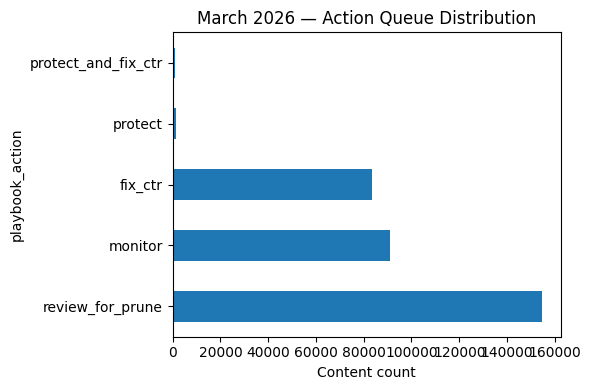

Figure saved to work/figures/w07_action_distribution.png


In [5]:
# A simple reusable figure for the paper
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
queue["playbook_action"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Content count")
ax.set_title("March 2026 — Action Queue Distribution")
plt.tight_layout()
plt.savefig("work/figures/w07_action_distribution.png", dpi=150)
plt.show()
print("Figure saved to work/figures/w07_action_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.